In [1]:
import pandas as pd 
import numpy as np 
from pathlib import Path
import pickle
from tqdm import tqdm

In [2]:
! hostname

node036


# Format Common Voice 9 


Load full corpora word alignments and pair with metadata to generate manifests for train, val, and test splits.

cv_all_word_alignments dataframe has fields:
* aud_path
* client_id
* gender
* origin_index
* word
* start_in_s
* end_in_s
* sr

Fields to add:
* dataset split (integer: 0=train, 1=valid, 2=test)
* word int label
* label talker sex int (integer: 0=female, 1=male, 2=other/intersex)


Commonvoice does not natively support speakerr identification, as the set of talkers in a given split (train,dev,test) are unique. We can create our own version if necessary.

We will filter for approximage speaker and gender balancing withtin splits. Will need to check if speakers are unique to train test val. If not, we will want to create a set with unique speakers per split. 


In [3]:
commonvoice_path = Path('/om2/user/imgriff/datasets/commonvoice_9/en/')


In [4]:
word_level_manifest = pd.read_pickle(commonvoice_path / "cv_all_word_alignments.pdpkl")

In [5]:
## Only want examples with native rate above 30kHz

word_level_manifest =  word_level_manifest[word_level_manifest.sr > 30_000]
word_level_manifest.head()

,aud_path,client_id,gender,origin_index,word,start_in_s,end_in_s,sr
0,common_voice_en_27710027.mp3,000abb3006b78ea4c1144e55d9d158f05a9db011016051...,NaN,0,JOE,0.762875,1.044000,32000
1,common_voice_en_27710027.mp3,000abb3006b78ea4c1144e55d9d158f05a9db011016051...,NaN,0,KEATON,1.064062,1.465563,32000
2,common_voice_en_27710027.mp3,000abb3006b78ea4c1144e55d9d158f05a9db011016051...,NaN,0,DISAPPROVED,1.505750,2.108062,32000
3,common_voice_en_27710027.mp3,000abb3006b78ea4c1144e55d9d158f05a9db011016051...,NaN,0,OF,2.188375,2.268687,32000
4,common_voice_en_27710027.mp3,000abb3006b78ea4c1144e55d9d158f05a9db011016051...,NaN,0,FILMS,2.369063,2.710375,32000


### Load list of talkers in each split

In [6]:
# convert to set for fast lookup

train_names = set(pd.read_csv(commonvoice_path / 'train.tsv', sep='\t',
                          usecols=['client_id'])['client_id'].unique())

val_names = set(pd.read_csv(commonvoice_path / 'dev.tsv',
                               sep='\t', usecols=['client_id'])['client_id'].unique())

test_names = set(pd.read_csv(commonvoice_path / 'test.tsv', sep='\t',
                         usecols=['client_id'])['client_id'].unique())




In [7]:
train_names.intersection(val_names)

set()

In [8]:
train_names.intersection(test_names)

set()

In [9]:
val_names.intersection(test_names)

set()

##### Find which split  each talker is in

In [10]:
def assign_to_split(talker,
                    train_names=train_names,
                    val_names=val_names,
                    test_names=test_names):
 
    if talker in train_names:
        data_split_str = 'train'
        data_split_int = 0
    elif talker in val_names:
        data_split_str = 'val'
        data_split_int = 1
    elif talker in test_names:
        data_split_str = 'test'
        data_split_int = 2
    else:
        return float('nan'), float('nan')
    return data_split_str, data_split_int


talkers = word_level_manifest['client_id'].unique()

splits = {talker:assign_to_split(talker) for talker in tqdm(talkers)}
# splits = {talker:split_data for talker, split_data in splits.items() if split_data!=None}
    

100%|██████████| 68946/68946 [00:00<00:00, 468106.07it/s]


In [11]:
split_str, split_int = zip(*word_level_manifest['client_id'].map(splits).values)

word_level_manifest['dataset_splits'] = split_str
word_level_manifest['dataset_split_int'] = split_int



In [12]:
word_level_manifest.dataset_splits.value_counts(dropna=False)

train    10062336
NaN       3798095
val        183778
test       172302
Name: dataset_splits, dtype: int64

### Get WSN/jSIN vocabulary

In [13]:
word_and_speaker_encodings = pickle.load( open( "/om2/user/imgriff/projects/Auditory-Attention/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
class_map = word_and_speaker_encodings['word_idx_to_word']

word_to_ix = {value.upper():int(key) for key, value in class_map.items()
             }
vocab = [word.upper() for word in class_map.values() if '__null' not in word]  # [1:] to cut '__nullSignal__'


#### Add word ints 

In [14]:
word_level_manifest['wsn_word_int'] = word_level_manifest['word'].map(word_to_ix)

In [15]:
word_level_manifest.head()

,aud_path,client_id,gender,origin_index,word,start_in_s,end_in_s,sr,dataset_splits,dataset_split_int,wsn_word_int
0,common_voice_en_27710027.mp3,000abb3006b78ea4c1144e55d9d158f05a9db011016051...,NaN,0,JOE,0.762875,1.044000,32000,test,2.0,NaN
1,common_voice_en_27710027.mp3,000abb3006b78ea4c1144e55d9d158f05a9db011016051...,NaN,0,KEATON,1.064062,1.465563,32000,test,2.0,NaN
2,common_voice_en_27710027.mp3,000abb3006b78ea4c1144e55d9d158f05a9db011016051...,NaN,0,DISAPPROVED,1.505750,2.108062,32000,test,2.0,NaN
3,common_voice_en_27710027.mp3,000abb3006b78ea4c1144e55d9d158f05a9db011016051...,NaN,0,OF,2.188375,2.268687,32000,test,2.0,NaN
4,common_voice_en_27710027.mp3,000abb3006b78ea4c1144e55d9d158f05a9db011016051...,NaN,0,FILMS,2.369063,2.710375,32000,test,2.0,NaN


### Save unfiltered manifest with added data

saved on March 16th 2023


In [16]:
# word_level_manifest.to_pickle(commonvoice_path / "cv_all_word_alignments_with_wsn_word_int_labels.pdpkl")

### Look at balence of unfiltered data

These are the commonvoice words, not the wsn vocabulary

<AxesSubplot:>

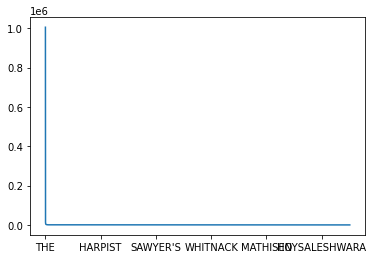

In [17]:
counts = word_level_manifest.word.value_counts(normalize=False)
counts.plot()

In [18]:
counts[:1000] #* len(word_level_manifest.word.unique())

THE           1005237
OF             357596
A              337237
AND            311097
TO             304286
               ...   
APPEAR           1554
SONS             1553
ACTIVITIES       1551
FORCES           1549
PAUL             1543
Name: word, Length: 1000, dtype: int64

(0.0, 30000.0)

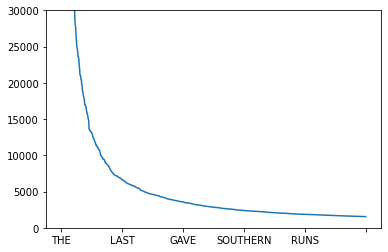

In [19]:
# top 1k 
import matplotlib.pyplot as plt
top_1k = counts[:1000]
top_1k_vocab = top_1k.index #* len(word_level_manifest.word.unique())
top_1k.plot()
plt.ylim(0,30000)

In [20]:
# new_words = word_level_manifest[word_level_manifest.word.isin(top_1k_vocab)].copy()

### Balance is poor - need to compute new vocab

Steps:
1. gender balance
2. compute most frequent words common to train, val, test
3. word frequency balance
4. talker balance

Start with `word_level_manifest`!!! 

### Gender balance

In [21]:
# Take same number of males as females
np.random.seed(0)

# get number of examples for gender classes
samples_per_gender = {gender:count for gender,count in word_level_manifest.gender.value_counts().items()}
# more males than females. Take all N female examples and only N male examples
samples_per_gender['male'] = samples_per_gender['female'] 
# show samples to draw per gender group
print(samples_per_gender)
# sample from all data
gend_bal_new = word_level_manifest.groupby('gender').apply(lambda group: group.sample(samples_per_gender[group.name]))
gend_bal_new = gend_bal_new.reset_index(drop=True)


{'male': 2355956, 'female': 2355956, 'other': 282924}


In [22]:
### Add gender int label 

gender_dict = {"female":0, "male":1, "other":2}

gend_bal_new['gender_int'] = gend_bal_new.gender.map(gender_dict)

In [23]:
gend_bal_new.head()

,aud_path,client_id,gender,origin_index,word,start_in_s,end_in_s,sr,dataset_splits,dataset_split_int,wsn_word_int,gender_int
0,common_voice_en_21721565.mp3,63e2659d2ae278fc14fcbce9bfba6788171021fe287d6c...,female,1176699,ROLE,2.306812,2.567625,48000,train,0.0,NaN,0
1,common_voice_en_25783384.mp3,7a63f8131f6bb4ef07803995e27468f277a1a4fa2971df...,female,279211,THE,2.587563,2.667750,32000,train,0.0,NaN,0
2,common_voice_en_27334252.mp3,e31822077e104d2f1781db7ce098c016abca0314515a35...,female,1421984,SHOWPIECE,3.516250,3.898000,32000,train,0.0,NaN,0
3,common_voice_en_20383167.mp3,57d9be2eeda5fbaad0290c45f4e95813da95e09633d5fd...,female,1455497,THE,2.530687,2.611063,48000,train,0.0,NaN,0
4,common_voice_en_22251472.mp3,05812a8b0aa7547db9c9e8ecf0fac06f46f8af06635de6...,female,807392,DOG,1.024063,1.265000,48000,train,0.0,NaN,0


### word balance

To find our vocabulary:
1. Compute word frequency in each subset of commonvoice
2. Rank by frequency in the training set.  
3. Limit vocabulary such that:
    * least frequent word occurs at least 100 times in the training
    * occurs at least once in both test and val set 

We will then balance word occurances in the training set by taking at most 5,000 occurances of each word via random sample without replacement.  

In [24]:
# get ordered word frequency in each split of the dataset 

word_balance_df = gend_bal_new.groupby(
    'dataset_splits').word.value_counts().unstack().T.dropna().sort_values('train', ascending=False)

In [25]:
# look at range of specific words 
word_balance_df.iloc[[0,10,990,1000]]

dataset_splits,test,train,val
word,,,
THE,818.0,288071.0,921.0
FOR,80.0,32817.0,115.0
TRADITION,2.0,317.0,3.0
ACTRESS,1.0,311.0,1.0


In [26]:
### Get vocab of top 1k words - df is already sorted 

cv_vocab = set(word_balance_df[:1000].index)

In [27]:
# filter for words in vocab 

gend_bal_filt = gend_bal_new[gend_bal_new.word.isin(cv_vocab)]

In [28]:
### look at new word frequency across dataset 
gend_bal_filt.word.value_counts()

THE               353305
OF                129759
A                 118047
AND               110736
TO                101767
                   ...  
RURAL                331
BASIS                331
ADMINISTRATION       327
SCIENTIFIC           326
INFLUENCED           323
Name: word, Length: 1000, dtype: int64

In [29]:
word_balance_df['test']['THE']

818.0

In [30]:
### Actual word balancing happens here 

upper_lim = 5000
np.random.seed(0)


# samples_per_word = {word:(count if count < upper_lim else upper_lim)
#                     for word,count in gend_bal_filt.word.value_counts().items()}

def get_n_words(split, word, upper_lim=upper_lim):
    count = word_balance_df[split][word]
    if count > upper_lim:
        return int(upper_lim)
    else:
        return int(count)
    
word_gen_bal = gend_bal_filt.groupby(
                        ['dataset_splits','word']).apply(
                        lambda group: group.sample( 
                            get_n_words(group.name[0], group.name[1])))

word_gen_bal = word_gen_bal.reset_index(drop=True)




In [31]:
word_gen_bal

,aud_path,client_id,gender,origin_index,word,start_in_s,end_in_s,sr,dataset_splits,dataset_split_int,wsn_word_int,gender_int
0,common_voice_en_22709692.mp3,1240a0e1f1076d55d54d13aab482fb23e437ff81206db5...,male,5759,A,2.226375,2.326625,48000,test,2.0,NaN,1
1,common_voice_en_553746.mp3,1283eb761582eff95a984a7c7df434295c656b1bc19347...,male,18561,A,2.662875,2.702875,48000,test,2.0,NaN,1
2,common_voice_en_25378349.mp3,43188a00125aad3b9a2aca9992955a31fbb13af6f96b6f...,male,7846,A,1.982938,2.023000,32000,test,2.0,NaN,1
3,common_voice_en_19933793.mp3,465f60a73dfa078b3396067358b1fb42607ce05af3baca...,female,7972,A,1.101500,1.121500,48000,test,2.0,NaN,0
4,common_voice_en_17857149.mp3,058b6a2cea9cd39533e230d1c9377d5849fb9959cb332c...,male,107,A,2.391688,2.431875,48000,test,2.0,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1293506,common_voice_en_46083.mp3,4dc00be70c01692a53f9e99c304c21e74a79bb6a8d9ad4...,male,25518,YOUR,2.782875,2.963062,48000,val,1.0,NaN,1
1293507,common_voice_en_17829980.mp3,3a4ec1fd6ed19a5b69141ffc89bf15153e0b6eb6be8f1a...,female,23094,YOUR,1.464438,1.584812,48000,val,1.0,NaN,0
1293508,common_voice_en_17245824.mp3,a1be96e406be6e06f0b16ab6097dfa83771997c685b949...,male,35460,YOUR,2.167813,2.288250,48000,val,1.0,NaN,1
1293509,common_voice_en_19940461.mp3,c4aecd9bb4e8ac70b1a7737c70d7ed6f05f9d703d5edc9...,other,39476,YOUTH,4.225375,4.405563,48000,val,1.0,NaN,2


In [32]:
new_word_freq = word_gen_bal.word.value_counts()
new_words = set(new_word_freq.index)
# top_1k = set(new_word_freq.index[:1000])

In [33]:
# top1_gend_bal = word_gen_bal[word_gen_bal.word.isin(top_1k)]

In [34]:
word_gen_bal.groupby('dataset_splits').word.value_counts().unstack().T.dropna().sort_values('train', ascending=False)



dataset_splits,test,train,val
word,,,
A,264,5000,374
AT,49,5000,58
THEIR,31,5000,19
THE,818,5000,921
WAS,142,5000,201
...,...,...,...
CONTRACT,2,313,3
EVERYONE,3,313,2
SELECTED,2,312,2


In [35]:
word_gen_bal.dataset_splits.value_counts()

train    1276651
val         8882
test        7978
Name: dataset_splits, dtype: int64

In [36]:
word_gen_bal.gender.value_counts()

female    621194
male      595504
other      76813
Name: gender, dtype: int64

### talker balance 

Now we sample from our talkers to impose a soft balance across voices in all datasets.  We will require at least 2 utterances per talker and at most 5000. 

So we can also use this corpus for a speaker identification task, we will first partition the most frequent talkers in the training set to their own training, val, and test subsets. We will then balance the ramining talkers in the training set 

In [37]:
### Check talker counts
talker_counts = word_gen_bal.client_id.value_counts()

In [38]:
cutoff = 2
print("N total talkers: ", len(talker_counts))

print(f"N total talkers with more than {cutoff} utterances {len(talker_counts[talker_counts >= cutoff])}")
print("Max from a single talker: ", talker_counts[talker_counts >= cutoff].max())
print("Min from a single talker: ", talker_counts[talker_counts >= cutoff].min())

N total talkers:  13554
N total talkers with more than 2 utterances 13283
Max from a single talker:  42963
Min from a single talker:  2


### Find most common talkers in training set 

In [39]:
train_talker_counts = word_gen_bal[word_gen_bal.dataset_splits=='train'].client_id.value_counts()

Text(0, 0.5, 'Occurance (log scale)')

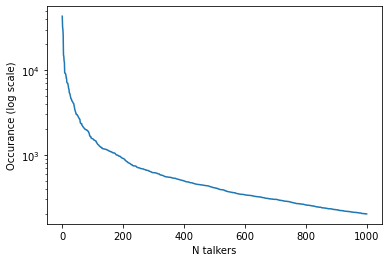

In [40]:
plt.plot(train_talker_counts.values[:1000])
plt.yscale('log')
plt.xlabel('N talkers')
plt.ylabel('Occurance (log scale)')

### Speaker identification set talkers 

Create "Base" training set with 500 most common talkers for joint speaker identification and word recognition task.  We will create a validation and test set using these voices as well.  

In [41]:
n_talkers = 500
spk_ident_voices = word_gen_bal[word_gen_bal.dataset_splits=='train'].client_id.value_counts().head(n_talkers)


np.random.seed(1)
upper_lim = 1000 # max num excerpts per talker
lower_lim = 2

def limit_count(count):
    if count < lower_lim:
        return 0 
    elif count > upper_lim:
        return upper_lim
    else:
        return count
        
# to_use = word_gen_bal[word_gen_bal.client_id.isin(set(wanted_talkers))]

samples_per_talker = {talker:limit_count(count)
                    for talker,count in spk_ident_voices.items()}


# draw from dataframe filtered to only have the top 1k words 
word_gen_bal['word_examp_ix'] = word_gen_bal.index
wanted_df = word_gen_bal[word_gen_bal.client_id.isin(set(samples_per_talker.keys()))]
bal_spk_ident_voices = wanted_df.groupby('client_id').apply(lambda group: group.sample(samples_per_talker[group.name]))
bal_spk_ident_voices = bal_spk_ident_voices.reset_index(drop=True)
bal_spk_ident_voices.head()

,aud_path,client_id,gender,origin_index,word,start_in_s,end_in_s,sr,dataset_splits,dataset_split_int,wsn_word_int,gender_int,word_examp_ix
0,common_voice_en_25174544.mp3,00309ae51fe07824676d5a3b39837b0a8927c064b7a054...,male,1393159,OVER,2.146063,2.286500,32000,train,0.0,NaN,1,795950
1,common_voice_en_25394077.mp3,00309ae51fe07824676d5a3b39837b0a8927c064b7a054...,male,1394116,COURSE,4.474250,4.775188,32000,train,0.0,170.0,1,247530
2,common_voice_en_25109522.mp3,00309ae51fe07824676d5a3b39837b0a8927c064b7a054...,male,1392656,THEY,2.244750,2.385063,32000,train,0.0,NaN,1,1075297
3,common_voice_en_25068142.mp3,00309ae51fe07824676d5a3b39837b0a8927c064b7a054...,male,1392083,CLUB,2.968875,3.249750,32000,train,0.0,NaN,1,218701
4,common_voice_en_24963699.mp3,00309ae51fe07824676d5a3b39837b0a8927c064b7a054...,male,1390950,STATE,5.274250,5.595125,32000,train,0.0,680.0,1,999010


Text(0.5, 0, 'Talker id')

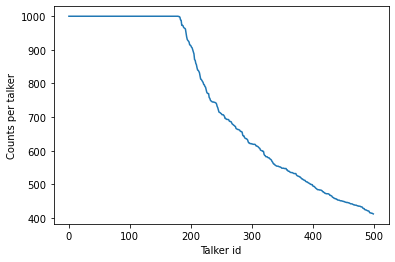

In [42]:
plt.plot(bal_spk_ident_voices.client_id.value_counts().values)
plt.ylabel('Counts per talker')
plt.xlabel('Talker id')

#### Make talker integer labels for voices in speaker identification set 

In [43]:
talker_label_dict = {talker:ix for ix, talker in enumerate(bal_spk_ident_voices.client_id.value_counts().sort_values(ascending=False).index)}

In [44]:
# write talker class map

save_dir = Path('/om2/user/imgriff/datasets/commonvoice_9/en')
out_name = save_dir / 'cv_talker_int_label_dict.pkl'

with open(out_name, 'wb') as file:
    pickle.dump(talker_label_dict, file, protocol=pickle.HIGHEST_PROTOCOL)

In [45]:
# add classes as column to pandas df 
bal_spk_ident_voices['cv_talker_int'] = bal_spk_ident_voices.client_id.map(talker_label_dict)
# add to main manifest too - will help screen rest of dataset for in/out of speaker ident task
word_gen_bal['cv_talker_int'] = word_gen_bal.client_id.map(talker_label_dict)

In [46]:
word_gen_bal.head()

,aud_path,client_id,gender,origin_index,word,start_in_s,end_in_s,sr,dataset_splits,dataset_split_int,wsn_word_int,gender_int,word_examp_ix,cv_talker_int
0,common_voice_en_22709692.mp3,1240a0e1f1076d55d54d13aab482fb23e437ff81206db5...,male,5759,A,2.226375,2.326625,48000,test,2.0,NaN,1,0,NaN
1,common_voice_en_553746.mp3,1283eb761582eff95a984a7c7df434295c656b1bc19347...,male,18561,A,2.662875,2.702875,48000,test,2.0,NaN,1,1,NaN
2,common_voice_en_25378349.mp3,43188a00125aad3b9a2aca9992955a31fbb13af6f96b6f...,male,7846,A,1.982938,2.023000,32000,test,2.0,NaN,1,2,NaN
3,common_voice_en_19933793.mp3,465f60a73dfa078b3396067358b1fb42607ce05af3baca...,female,7972,A,1.101500,1.121500,48000,test,2.0,NaN,0,3,NaN
4,common_voice_en_17857149.mp3,058b6a2cea9cd39533e230d1c9377d5849fb9959cb332c...,male,107,A,2.391688,2.431875,48000,test,2.0,NaN,1,4,NaN


### Make Speaker identification train, val, test splits 

In [47]:
np.random.seed(0)

bal_spk_ident_voices['spk_ident_task_index'] = bal_spk_ident_voices.index


# take 5% of samples for val and test - split this 50/50 for test and val 
val_split_size = 0.05
samples_per_talker = {talker: int(count * val_split_size)
                    for talker,count in bal_spk_ident_voices.client_id.value_counts().items()}


# draw from speaker ident dataframe 
val_and_test_set_voices_df = bal_spk_ident_voices.groupby('client_id').apply(lambda group: group.sample(samples_per_talker[group.name]))
val_and_test_set_voices_df = val_and_test_set_voices_df.reset_index(drop=True) 
print("Total val & test samples = ", val_and_test_set_voices_df.shape)

# get val & test set example ids 
val_and_test_set_examp_ixs = set(val_and_test_set_voices_df.spk_ident_task_index)

# get training set split
train_spk_ident_df = bal_spk_ident_voices[~bal_spk_ident_voices.spk_ident_task_index.isin(val_and_test_set_examp_ixs)]
train_set_examp_ixs = set(train_spk_ident_df.spk_ident_task_index)
print(f"Total training set size = {train_spk_ident_df.shape}")

# sample for test set 
test_split_size = 0.5 ## half of samples go to val, half go to test 
samples_per_test_talker = {talker: int(count * test_split_size)
                    for talker,count in val_and_test_set_voices_df.client_id.value_counts().items()}

# draw val examples from val_and_test dataframe 
val_spk_ident_df = val_and_test_set_voices_df.groupby('client_id').apply(lambda group: group.sample(samples_per_test_talker[group.name]))
val_spk_ident_df = val_spk_ident_df.reset_index(drop=True) 
val_set_examp_ixs = set(val_spk_ident_df.spk_ident_task_index)
assert len(train_set_examp_ixs.intersection(val_set_examp_ixs)) == 0, "Exclusivitiy failed: training examples in validation set!!"
print("Total val samples = ", val_spk_ident_df.shape)

# get test split examples 
test_spk_ident_df = val_and_test_set_voices_df[~val_and_test_set_voices_df.spk_ident_task_index.isin(val_set_examp_ixs)]
test_set_examp_ixs = set(test_spk_ident_df.spk_ident_task_index)

assert len(train_set_examp_ixs.intersection(val_set_examp_ixs)) == 0, "Exclusivitiy failed: training examples in validation set!!"
assert len(val_set_examp_ixs.intersection(test_set_examp_ixs)) == 0, "Exclusivitiy failed: validation examples in test set!!"
print("Total test samples = ", test_spk_ident_df.shape)


Total val & test samples =  (18488, 15)
Total training set size = (354358, 15)
Total val samples =  (9161, 15)
Total test samples =  (9327, 15)


In [48]:
### Create mask of client ids for speaker ident task

train_map_dict = {word_examp_ix:'train' for word_examp_ix in train_spk_ident_df.word_examp_ix.unique()}

val_map_dict = {word_examp_ix:'val' for word_examp_ix in val_spk_ident_df.word_examp_ix.unique()}

test_map_dict = {word_examp_ix:'test' for word_examp_ix in test_spk_ident_df.word_examp_ix.unique()}

speak_ident_split_map = train_map_dict | val_map_dict | test_map_dict # merge dicts 

# assign to word_bal df 

word_gen_bal['cv_speaker_ident_split'] = word_gen_bal.word_examp_ix.map(speak_ident_split_map)

# add to speaker ident dfs
train_spk_ident_df['cv_speaker_ident_split'] = train_spk_ident_df.word_examp_ix.map(speak_ident_split_map)
val_spk_ident_df['cv_speaker_ident_split'] = val_spk_ident_df.word_examp_ix.map(speak_ident_split_map)
test_spk_ident_df['cv_speaker_ident_split'] = test_spk_ident_df.word_examp_ix.map(speak_ident_split_map)


/tmp/ipykernel_4565/1136758010.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_spk_ident_df['cv_speaker_ident_split'] = train_spk_ident_df.word_examp_ix.map(speak_ident_split_map)
/tmp/ipykernel_4565/1136758010.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_spk_ident_df['cv_speaker_ident_split'] = test_spk_ident_df.word_examp_ix.map(speak_ident_split_map)


### Make word recognition train, val, test splits 

In [49]:
## Exclude speaker identification examples from this training set 
train_talkers = word_gen_bal[(word_gen_bal.dataset_splits=='train') & (word_gen_bal['cv_speaker_ident_split'].isna())].client_id.unique()

val_talkers = word_gen_bal[word_gen_bal.dataset_splits=='val'].client_id.unique()

test_talkers = word_gen_bal[word_gen_bal.dataset_splits=='test'].client_id.unique()

wanted_talkers = set(np.concatenate([train_talkers, val_talkers, test_talkers]))
print(len(wanted_talkers))

13234


Limit number of talkers in splits. We keep all validation and test set talker occurances since they are all below our upper limit

In [51]:
np.random.seed(1)
upper_lim = 2000 # max num excerpts per talker
lower_lim = 2

def limit_count(count):
    if count < lower_lim:
        return 0 
    elif count > upper_lim:
        return upper_lim
    else:
        return count
        
to_use = word_gen_bal[word_gen_bal.client_id.isin(set(wanted_talkers))]

samples_per_talker = {talker:limit_count(count)
                    for talker,count in to_use.client_id.value_counts().items()}


# draw from dataframe filtered to only have the top 1k words 
talker_word_gend_bal = to_use.groupby('client_id').apply(lambda group: group.sample(samples_per_talker[group.name]))
talker_word_gend_bal = talker_word_gend_bal.reset_index(drop=True)


In [52]:
### Check word count after talker balance
fin_word_freq = talker_word_gend_bal.word.value_counts()
cv_words = set(fin_word_freq.index)
top_1k = set(fin_word_freq.index[:1000])

In [53]:
### Check dataset split sizes
talker_word_gend_bal.dataset_splits.value_counts()

train    763205
val        8869
test       7816
Name: dataset_splits, dtype: int64

In [54]:
### Check gender balance

talker_word_gend_bal.groupby('dataset_splits').gender.value_counts()

dataset_splits  gender
test            male        4872
                female      2654
                other        290
train           male      405756
                female    323364
                other      34085
val             male        5458
                female      3168
                other        243
Name: gender, dtype: int64

In [55]:
### Final word balance across dattasets

# get ordered word frequency in each split of the dataset 

fin_word_balance_df = talker_word_gend_bal.groupby(
    'dataset_splits').word.value_counts().unstack().T.sort_values('train', ascending=False).dropna()

In [56]:
### Final word balance across datasets

fin_word_balance_df

dataset_splits,test,train,val
word,,,
YOU,75.0,3202.0,82.0
I,54.0,3179.0,76.0
NO,21.0,3138.0,21.0
ONE,33.0,3081.0,36.0
HAVE,44.0,3078.0,50.0
...,...,...,...
PASSES,1.0,175.0,2.0
MEDAL,1.0,175.0,3.0
SCIENTIFIC,1.0,172.0,2.0


In [57]:
## Make vocab dict:
cv_word_vocab_dict = {word.lower():ix for ix,word in enumerate(fin_word_balance_df.index)}

# write talker class map

out_name = commonvoice_path / 'cv_word_int_label_dict.pkl'

with open(out_name, 'wb') as file:
    pickle.dump(cv_word_vocab_dict, file, protocol=pickle.HIGHEST_PROTOCOL)


In [58]:
### Get final counts after selecting for valid words
final_vocab = set(fin_word_balance_df.index)

final_df = talker_word_gend_bal[talker_word_gend_bal.word.isin(final_vocab)]


In [59]:
### Add word ints to final df

final_df['cv_word_int'] = final_df['word'].str.lower().map(cv_word_vocab_dict)

/tmp/ipykernel_4565/1692258584.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df['cv_word_int'] = final_df['word'].str.lower().map(cv_word_vocab_dict)


In [60]:
final_df.client_id.unique().shape

(12963,)

In [61]:
## Final gender balance 

final_df.groupby('dataset_splits').gender.value_counts(normalize=True).round(2)

dataset_splits  gender
test            male      0.62
                female    0.34
                other     0.04
train           male      0.53
                female    0.42
                other     0.04
val             male      0.62
                female    0.36
                other     0.03
Name: gender, dtype: float64

In [62]:
### Final talker occurances 
final_df.groupby(
    'dataset_splits').client_id.value_counts().unstack().T.max()


dataset_splits
test       32.0
train    2000.0
val        36.0
dtype: float64

In [63]:
### Final dataset split sizes
final_df.dataset_splits.value_counts()

train    762875
val        8868
test       7816
Name: dataset_splits, dtype: int64

### Get balance of talkers in training set 


In [64]:
talkers = final_df[final_df.dataset_splits=='train'].client_id.value_counts()

In [65]:
print(f"N with over 1k examples each: {len(talkers) - len(talkers[talkers<1000])} (prop. of training set = {talkers[talkers>=1000].sum()/talkers.sum():.2f})")
print(f"N with under 1k examples each {len(talkers[talkers<1000]) } (prop. of training set = {talkers[talkers<1000].sum()/talkers.sum()})")

N with over 1k examples each: 180 (prop. of training set = 0.38)
N with under 1k examples each 10552 (prop. of training set = 0.6171758151728658)


## Save final dataframes 

Save final word rec manifest

In [66]:
final_df.to_pickle(commonvoice_path / 'manifests/full_word_rec_manifest.pdpkl')



In [67]:
train_word_rec_df = final_df[final_df['dataset_splits'] == 'train'].reset_index(drop=True)
val_word_rec_df = final_df[final_df['dataset_splits'] == 'val'].reset_index(drop=True)
test_word_rec_df = final_df[final_df['dataset_splits'] == 'test'].reset_index(drop=True)

In [68]:
## Save word rec splits 

train_word_rec_df.to_pickle( commonvoice_path / 'manifests/cv_word_rec_train_split_manifest.pdpkl')
val_word_rec_df.to_pickle( commonvoice_path / 'manifests/cv_word_rec_val_split_manifest.pdpkl')
test_word_rec_df.to_pickle( commonvoice_path / 'manifests/cv_word_rec_test_split_manifest.pdpkl')

Add word ints and save speaker identification manifests

In [69]:
train_spk_ident_df['cv_word_int'] = train_spk_ident_df['word'].str.lower().map(cv_word_vocab_dict)
print("Len train before cut: ", len(train_spk_ident_df))
train_spk_ident_df = train_spk_ident_df[~train_spk_ident_df['cv_word_int'].isna()]
print("Len train after cut: ", len(train_spk_ident_df))

val_spk_ident_df['cv_word_int'] = val_spk_ident_df['word'].str.lower().map(cv_word_vocab_dict)
print("Len val before cut: ", len(val_spk_ident_df))
val_spk_ident_df = val_spk_ident_df[~val_spk_ident_df['cv_word_int'].isna()]
print("Len val after cut: ", len(val_spk_ident_df))

test_spk_ident_df['cv_word_int'] = test_spk_ident_df['word'].str.lower().map(cv_word_vocab_dict)
print("Len test before cut: ", len(test_spk_ident_df))
test_spk_ident_df = test_spk_ident_df[~test_spk_ident_df['cv_word_int'].isna()]
print("Len test after cut: ", len(test_spk_ident_df))


Len train before cut:  354358
Len train after cut:  354204
Len val before cut:  9161
Len val after cut:  9158
Len test before cut:  9327
Len test after cut:  9323


/tmp/ipykernel_4565/3575994008.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_spk_ident_df['cv_word_int'] = train_spk_ident_df['word'].str.lower().map(cv_word_vocab_dict)
/tmp/ipykernel_4565/3575994008.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_spk_ident_df['cv_word_int'] = test_spk_ident_df['word'].str.lower().map(cv_word_vocab_dict)


### Speaker identification splits

In [71]:
train_spk_ident_df.to_pickle( commonvoice_path / 'manifests/cv_speaker_ident_train_split_manifest.pdpkl')
val_spk_ident_df.to_pickle( commonvoice_path / 'manifests/cv_speaker_ident_val_split_manifest.pdpkl')
test_spk_ident_df.to_pickle( commonvoice_path / 'manifests/cv_speaker_ident_test_split_manifest.pdpkl')

# Old examples 
## Alternate set

In [311]:
# Take same number of males as females

samples_per_gender = {gender:count for gender,count in gend_bal_new.gender.value_counts().items()}
samples_per_gender['male'] = samples_per_gender['female'] 
# print(samples_per_talker)
word_bal_gend_bal_new = gend_bal_new.groupby('gender').apply(lambda group: group.sample(samples_per_gender[group.name]))
word_bal_gend_bal_new = word_bal_gend_bal_new.reset_index(drop=True)


## Cut to exclude out of vocabulary excerpts 

In [312]:
valid_manifest = word_level_manifest.dropna(subset=['word_int'])

In [313]:
valid_manifest['word_int'] = valid_manifest['word_int'].astype('int', copy=False)

/tmp/ipykernel_39514/1424092925.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_manifest['word_int'] = valid_manifest['word_int'].astype('int', copy=False)


## Look at balance post cutting oovs and unplaced talkers

In [314]:
# dataset split
valid_manifest.dataset_splits.value_counts(dropna=False)

train    1517148
NaN       404747
test       25971
val        15868
Name: dataset_splits, dtype: int64

In [129]:
commonvoice_path

PosixPath('/scratch2/weka/mcdermott/imgriff/datasets/commonvoice_9/en')

In [315]:
valid_manifest.groupby('dataset_splits').gender.value_counts(dropna=False)

dataset_splits  gender
test            NaN        22215
                male        3066
                female       625
                other         65
train           male      802300
                NaN       364311
                female    311254
                other      39283
val             NaN        13401
                male        1995
                female       449
                other         23
Name: gender, dtype: int64

In [127]:
valid_manifest.to_pickle(commonvoice_path / "cv_word_alignments_with_labels_no_wsn_oov.pdpkl")

In [128]:
!ls {commonvoice_path}

alignment_dfs
clips
cv_all_alignments_pre_cut.pdpkl
cv_all_word_alignments.pdpkl
cv_all_word_alignments_with_labels.pdpkl
cv_gender_balanced_word_alignments_with_labels.pdpkl
cv_test_set_wsn_vocab_word_alignments.pdpkl
cv_test_set_wsn_vocab_word_alignments_gender_balanced.pdpkl
cv_test_set_wsn_vocab_word_alignments_gender_balanced_48kHz_sr.pdpkl
cv_test_set_wsn_vocab_word_alignments_gender_balanced_all_sr.pdpkl
cv_word_alignments_with_labels_no_wsn_oov.pdpkl
dev.tsv
invalidated.tsv
other.tsv
reported.tsv
test.tsv
train.tsv
validated.tsv


In [97]:
%matplotlib inline
import seaborn as sns

<AxesSubplot:>

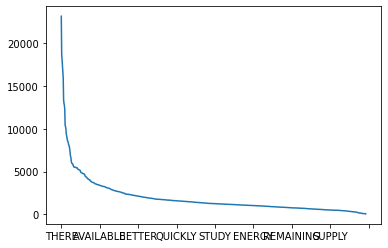

In [98]:
## Plot word frequency



valid_manifest[valid_manifest.dataset_splits =='train'].word.value_counts().plot()

In [103]:
folded_manifest = valid_manifest.copy()

In [104]:
folded_manifest['dataset_splits'][folded_manifest['dataset_splits'].isna()] = 'train'

/tmp/ipykernel_23052/412571450.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  folded_manifest['dataset_splits'][folded_manifest['dataset_splits'].isna()] = 'train'


In [105]:
folded_manifest

,aud_path,client_id,gender,origin_index,word,start_in_s,end_in_s,sr,dataset_splits,dataset_split_int,word_int
1,common_voice_en_25122853.mp3,a06c1e43eb54d527b2f07c95637d6580b6251481f9cf96...,NaN,341005,GROUP,0.423000,0.664687,32000,train,0.0,305
5,common_voice_en_25122853.mp3,a06c1e43eb54d527b2f07c95637d6580b6251481f9cf96...,NaN,341005,GIVEN,1.692000,1.933688,32000,train,0.0,297
14,common_voice_en_25124753.mp3,a06c1e43eb54d527b2f07c95637d6580b6251481f9cf96...,NaN,341006,RECEIVED,1.824750,2.205750,32000,train,0.0,576
17,common_voice_en_25124753.mp3,a06c1e43eb54d527b2f07c95637d6580b6251481f9cf96...,NaN,341006,NATIONAL,2.426312,2.787313,32000,train,0.0,445
18,common_voice_en_25124753.mp3,a06c1e43eb54d527b2f07c95637d6580b6251481f9cf96...,NaN,341006,PRESS,2.847437,3.068000,32000,train,0.0,528
...,...,...,...,...,...,...,...,...,...,...,...
12674151,common_voice_en_17406466.mp3,96ca33cd96d24f512b85bdb25829ef836e0702355b7e11...,male,263501,MIGHT,6.577375,6.777875,48000,train,NaN,427
12674165,common_voice_en_17406468.mp3,96ca33cd96d24f512b85bdb25829ef836e0702355b7e11...,male,263503,NEARLY,1.842313,2.302938,48000,train,NaN,449
12674172,common_voice_en_17406468.mp3,96ca33cd96d24f512b85bdb25829ef836e0702355b7e11...,male,263503,THEIR,5.487000,5.627187,48000,train,NaN,712
12674175,common_voice_en_17406469.mp3,96ca33cd96d24f512b85bdb25829ef836e0702355b7e11...,male,263504,COULD,1.643063,1.803375,48000,train,NaN,167


<AxesSubplot:>

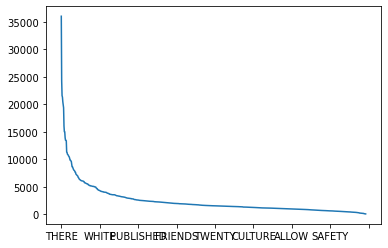

In [106]:
folded_manifest[folded_manifest.dataset_splits =='train'].word.value_counts().plot()

In [107]:
folded_manifest[folded_manifest.dataset_splits =='train'].word.value_counts()


THERE         36050
THEIR         24293
AFTER         21594
FIRST         21318
OTHER         20445
              ...  
SEVENTY          81
INFLATION        75
SECURITIES       71
SPOKESMAN        69
ANALYSTS         41
Name: word, Length: 793, dtype: int64

## Gender balance then compare distributions

In [317]:
valid_manifest.gender.value_counts(dropna=False)

male      961689
NaN       603985
female    354439
other      43621
Name: gender, dtype: int64

In [319]:
# Take same number of males as females

samples_per_gender = {gender:count for gender,count in valid_manifest.gender.value_counts().items()}
samples_per_gender['male'] = samples_per_gender['female'] 
# print(samples_per_talker)
valid_gender_balanced_manifest = valid_manifest.groupby('gender').apply(lambda group: group.sample(samples_per_gender[group.name]))
valid_gender_balanced_manifest = valid_gender_balanced_manifest.reset_index(drop=True)


### Look at distribution after cutting 

In [320]:
valid_gender_balanced_manifest.dataset_splits.value_counts(dropna=False)

train    646124
NaN      103303
test       1833
val        1239
Name: dataset_splits, dtype: int64

<AxesSubplot:>

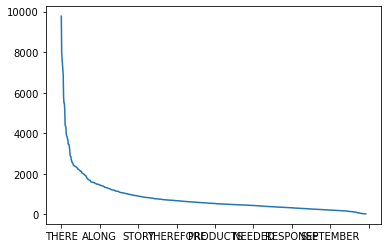

In [321]:
valid_gender_balanced_manifest[valid_gender_balanced_manifest.dataset_splits =='train'].word.value_counts().plot()

In [322]:
valid_gender_balanced_manifest[valid_gender_balanced_manifest.dataset_splits =='train'].word.value_counts().min()

22

#### Cut to exclude unassigned talkers and save

These likely failed common voices validation & quality control criteria 

In [125]:
valid_gender_balanced_manifest = valid_gender_balanced_manifest.dropna(subset=['dataset_splits'])

In [126]:
valid_gender_balanced_manifest.to_pickle(commonvoice_path / "cv_gender_balanced_word_alignments_with_labels.pdpkl")